# XGBoost

## Importaciones

In [1]:
import time
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

In [4]:
from xgboost import XGBClassifier

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold

In [6]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

## Cargado de datos

In [7]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((170152, 14), (42539, 14), (170152, 1), (42539, 1))

In [9]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

## Funciones usadas

In [10]:
from funciones import *

## Modelo XGBoost

In [11]:
mapping = {"Low": 0, "Medium": 1, "High": 2}
y_train_enc = y_train.map(mapping)
y_test_enc = y_test.map(mapping)
labels = list(mapping.values())              
target_names = list(mapping.keys())  

In [12]:
pipe_XGBoost=crear_pipeline(XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=0,
    max_depth=3,
    min_child_weight=10,
    subsample=0.4,
    colsample_bytree=0.4,
    reg_alpha=10.0,
    reg_lambda=2.0,
    learning_rate=0.03,
    n_estimators=80,       
    max_delta_step=1
), tipo="normal")

In [13]:
start = time.time()
model_pipe = pipe_XGBoost.fit(X_train,y_train_enc)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.03 minutos


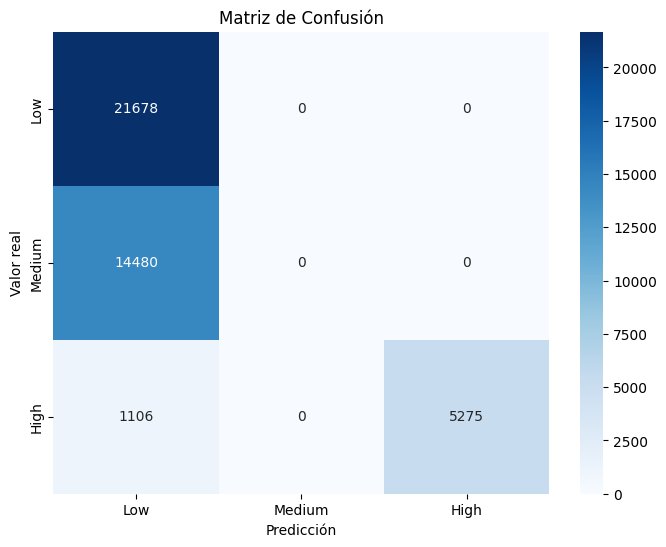


Classification Report:

              precision    recall  f1-score   support

         Low       0.58      1.00      0.74     21678
      Medium       0.00      0.00      0.00     14480
        High       1.00      0.83      0.91      6381

    accuracy                           0.63     42539
   macro avg       0.53      0.61      0.55     42539
weighted avg       0.45      0.63      0.51     42539



{'Accuracy': 0.6336068078704248,
 'Precision (macro)': 0.5272470301989408,
 'Recall (macro)': 0.6088909784255342,
 'F1-score (macro)': 0.5468946024290241,
 'ROC-AUC': 0.7535900325047837}

In [14]:
evaluar_modelo(model_pipe, X_test, y_test_enc, class_map=mapping)

En general se puede observar que hay un desbalance muy grande en el modelo, medium tiene scores de 0 en las metricas por clase, y Low y High tienen scores de 1 en precision y recall respectivamente en que se debe al balanceo. Las metricas generales rondan 0.53-0.63 salvo AUC con 0.75

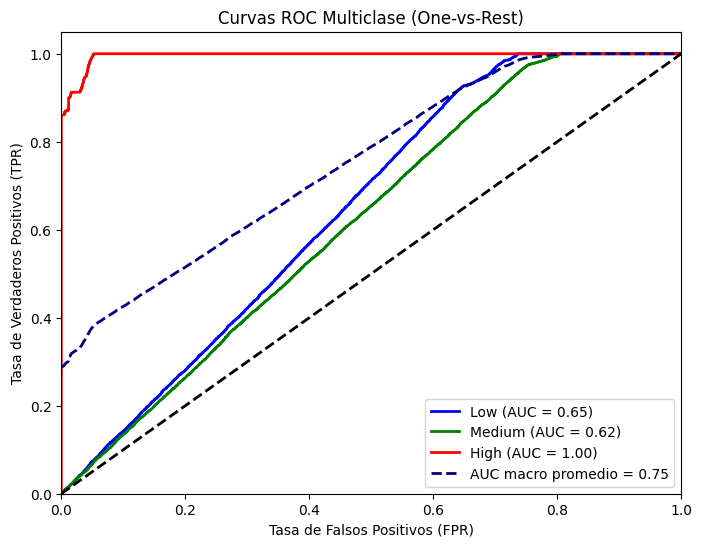

In [15]:
plot_roc_multiclass2(model_pipe, X_test, y_test)

## Balance de modelo

### SMOTE

In [16]:
pipe_XGBoost_bal=crear_pipeline(XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=0,
    max_depth=3,
    min_child_weight=10,
    subsample=0.4,
    colsample_bytree=0.4,
    reg_alpha=10.0,
    reg_lambda=2.0,
    learning_rate=0.03,
    n_estimators=80,       # clave
    max_delta_step=1
), tipo="balanceo_smote",y_train=y_train_enc)

In [17]:
start = time.time()
model_pipe_bal = pipe_XGBoost_bal.fit(X_train,y_train_enc)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.15 minutos


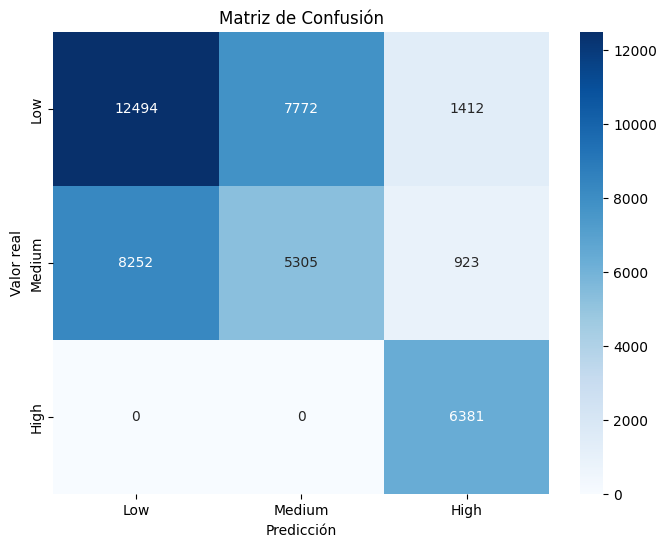


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.58      0.59     21678
      Medium       0.41      0.37      0.39     14480
        High       0.73      1.00      0.85      6381

    accuracy                           0.57     42539
   macro avg       0.58      0.65      0.61     42539
weighted avg       0.55      0.57      0.56     42539



{'Accuracy': 0.5684195679259033,
 'Precision (macro)': 0.5800041805308656,
 'Recall (macro)': 0.647570694852858,
 'F1-score (macro)': 0.6064532909782909,
 'ROC-AUC': 0.7552973458229969}

In [18]:
evaluar_modelo(model_pipe_bal, X_test, y_test_enc, class_map=mapping)

Podemos observar que incluso luego del balanceo por SMOTE, Medium tiene valores bajos en recall y F1, aunque si es una mejora en comparacion con el modelo benchmark no balanceado, aunque recall ahora esta en un perfecto 1 en High y hubo un bajon leve en accuracy con 0.58 pero recall mejoro con 0.65 

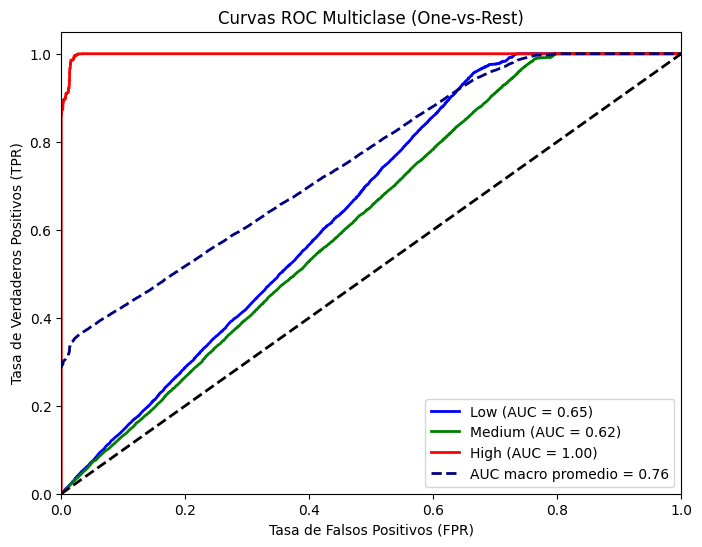

In [19]:
plot_roc_multiclass2(model_pipe_bal, X_test, y_test)

### ADASYN

In [20]:
pipe_XGBoost_ads=crear_pipeline(XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=0,
    max_depth=3,
    min_child_weight=10,
    subsample=0.4,
    colsample_bytree=0.4,
    reg_alpha=10.0,
    reg_lambda=2.0,
    learning_rate=0.03,
    n_estimators=80,       # clave
    max_delta_step=1
), tipo="balanceo_adasyn",y_train=y_train_enc)

In [21]:
start = time.time()
model_pipe_ads = pipe_XGBoost_ads.fit(X_train,y_train_enc)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.40 minutos


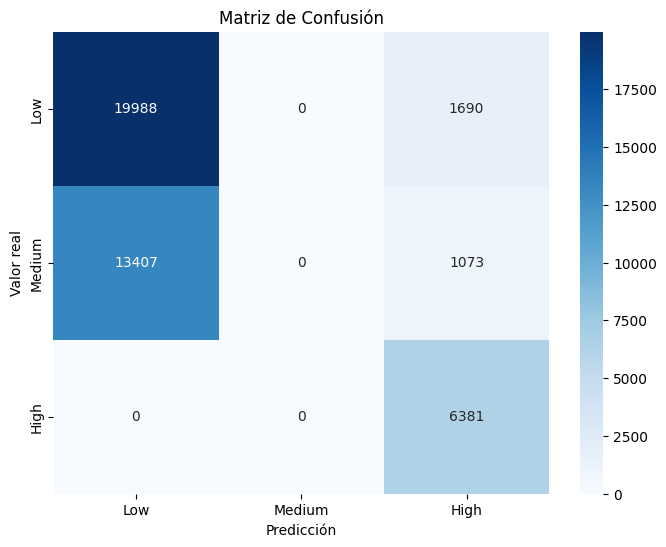


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.92      0.73     21678
      Medium       0.00      0.00      0.00     14480
        High       0.70      1.00      0.82      6381

    accuracy                           0.62     42539
   macro avg       0.43      0.64      0.52     42539
weighted avg       0.41      0.62      0.49     42539



{'Accuracy': 0.6198782293895014,
 'Precision (macro)': 0.43212245338250216,
 'Recall (macro)': 0.6406802595565396,
 'F1-score (macro)': 0.5159673059323721,
 'ROC-AUC': 0.7558216480356365}

In [22]:
evaluar_modelo(model_pipe_ads, X_test, y_test_enc, class_map=mapping)

El balanceo por ADASYN no ayudo a la mejora del modelo, con scores casi iguales no se observa una mejora significativa en comparacion al original o al balanceado por SMOTE, salvo accuracy que ahora tiene 0.63 y recall con 0.646  

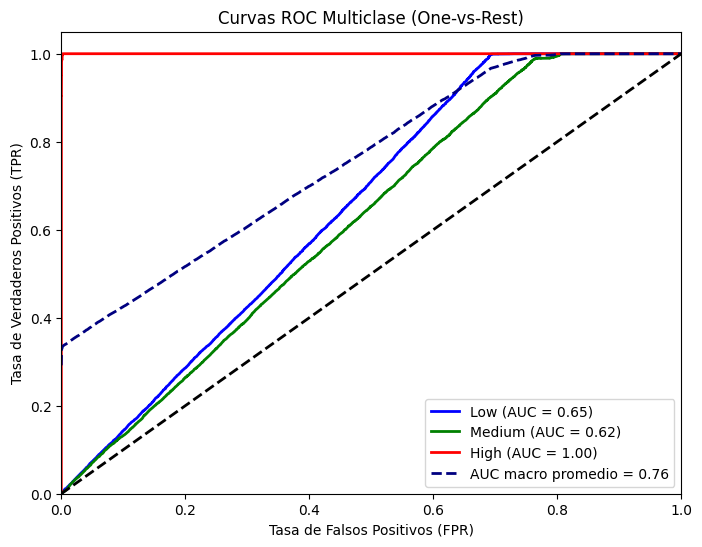

In [23]:
plot_roc_multiclass2(model_pipe_ads, X_test, y_test)

## Optimizacion computacional

In [24]:
pipe_XGBoost_opt = crear_pipeline(
    XGBClassifier(
        objective="multi:softprob",   # Clasificación multiclase
        num_class=3,                  # Número de clases
        eval_metric="mlogloss",       # Métrica multiclase
        tree_method="hist",           # Entrenamiento rápido
        random_state=0,
        max_depth=3,
        min_child_weight=10,
        subsample=0.4,
        colsample_bytree=0.4,
        reg_alpha=10.0,
        reg_lambda=2.0,
        learning_rate=0.03,
        n_estimators=80,       # clave
        max_delta_step=1
    ),
    tipo="balanceo_smote",
    y_train=y_train_enc
)

In [25]:
start = time.time()
model_pipe_opt = pipe_XGBoost_opt.fit(
    X_train,
    y_train_enc,
)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.13 minutos


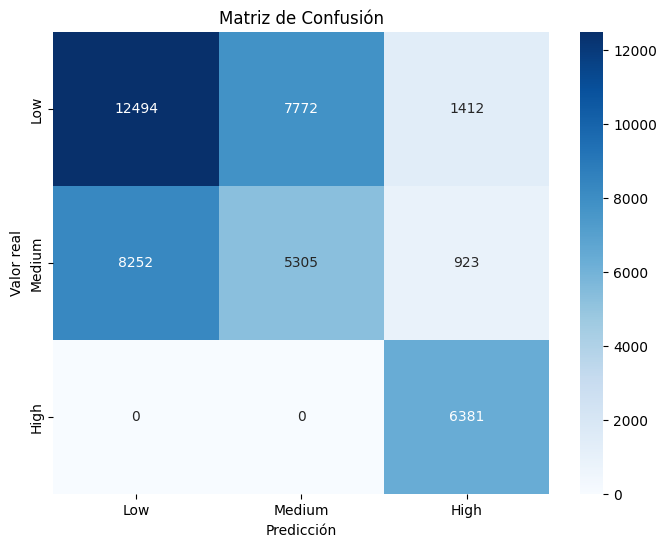


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.58      0.59     21678
      Medium       0.41      0.37      0.39     14480
        High       0.73      1.00      0.85      6381

    accuracy                           0.57     42539
   macro avg       0.58      0.65      0.61     42539
weighted avg       0.55      0.57      0.56     42539



{'Accuracy': 0.5684195679259033,
 'Precision (macro)': 0.5800041805308656,
 'Recall (macro)': 0.647570694852858,
 'F1-score (macro)': 0.6064532909782909,
 'ROC-AUC': 0.7552973458229969}

In [26]:
evaluar_modelo(model_pipe_opt, X_test, y_test_enc, class_map=mapping)


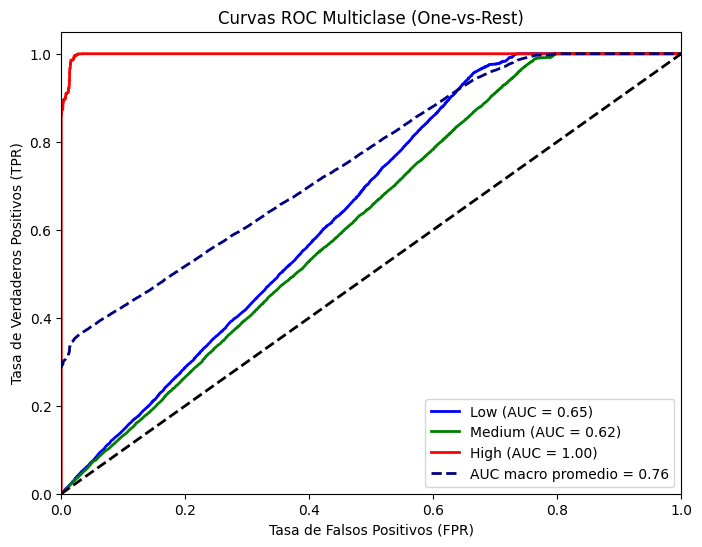

In [27]:
plot_roc_multiclass2(model_pipe_opt, X_test, y_test)

## Tabla comparativa

| XGBoost    | Accuracy | Precision_macro | Recall_macro | F1-macro | AUC  | Tiempo en minutos
|---------------|----------|----------|--------|----------|------|------|
| Benchmark      | 0.63     | 0.53     | 0.60   | 0.54    | 0.75 | 0.06
| SMOTE     | 0.58     | 0.59     | 0.65   | 0.62     | 0.75 | 0.31
| ADASYN     | 0.63    | 0.45     | 0.65   | 0.53     | 0.76 |0.94
| Optimizacion | 0.58  | 0.59     | 0.65   | 0.62    | 0.75 | 0.28

## Lime 

In [28]:

from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

pipes = {
    "normal": pipe_XGBoost,
    "smote": pipe_XGBoost_bal,
    "adasyn": pipe_XGBoost_ads
}

if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train)
if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test)

fila = 0 

def separar_transformador_y_modelo(pipe):
    if not isinstance(pipe, Pipeline):
        raise ValueError("El objeto no es un Pipeline.")

    transformadores = []
    for name, step in pipe.steps:
        if hasattr(step, "transform") or hasattr(step, "fit_transform"):
            transformadores.append((name, step))
        else:
            break
    preprocessor = Pipeline(transformadores) if transformadores else None

    for name, step in reversed(pipe.steps):
        if hasattr(step, "predict_proba"):
            return preprocessor, step
    raise ValueError("No se encontró clasificador con predict_proba en el pipeline.")

for nombre, modelo in pipes.items():
    print(f"\n--- Generando LIME para modelo: {nombre.upper()} ---")

    preprocessor, classifier = separar_transformador_y_modelo(modelo)

    if preprocessor is not None:
        X_train_trans = preprocessor.transform(X_train)
        X_test_trans = preprocessor.transform(X_test)
        try:
            feature_names = preprocessor.get_feature_names_out()
        except Exception:
            feature_names = [f"f_{i}" for i in range(X_train_trans.shape[1])]
    else:
        X_train_trans = X_train.values
        X_test_trans = X_test.values
        feature_names = X_train.columns.tolist()

    explainer = LimeTabularExplainer(
        training_data=np.array(X_train_trans),
        feature_names=feature_names,
        class_names=[str(c) for c in np.unique(y_train)],
        mode="classification",
        discretize_continuous=True
    )

    def pred_fn(x):
        return classifier.predict_proba(x)
    
    exp = explainer.explain_instance(
        data_row=X_test_trans[fila],
        predict_fn=pred_fn
    )

    exp.show_in_notebook(show_table=True, show_all=False)
    exp.save_to_file(f"lime_{nombre}.html")



--- Generando LIME para modelo: NORMAL ---



--- Generando LIME para modelo: SMOTE ---



--- Generando LIME para modelo: ADASYN ---
